# Тесты модели расчетов

In [1]:
from nrs import EType, NRS_Model, Element, NRS_Revision, NRS_Observer_E    # классы НРС
from nrs import NRS_Data as nd                                      # Табличные данные НРС
from nrs import q_out_simple, q_out_nozzle                          # модели расчета параметров
import matplotlib.pyplot as plt                                     # библиотеки для отрисовки получаемых данных

## Проблема отказа при больших разбегах невязки

Имеют место случаи, когда система может быть рассчитана, однако с использованием расчетной модели на итерационной релаксации она нерассчитываемеа

Модель:

In [2]:
# Проводимости насадков
p_2 = NRS_Revision.calc_p(2.16, 40)
p_4 = NRS_Revision.calc_p(4.85, 40)
p_6 = NRS_Revision.calc_p(6, 40)
p_8 = NRS_Revision.calc_p(8.61, 40)
p_10 = NRS_Revision.calc_p(10, 40)


# Сопротивление одного рукава 51 мм, эмпирическое:
ss51 = 0.09

# Создаем модель НРС:
model = NRS_Model('Модель от одного насоса к одному стволу')

# Создаем элементы модели:
pump   = Element('Н1', EType.PUMP, H_add=40)                                       # Насос
hose   = Element('РРЛ Р1-1', EType.CONNECTOR, s = ss51, n=5)                   # рабочая рукавная линия
nozzle = Element('Ствол 1', EType.NOZZLE, p = p_10, q_out = q_out_nozzle)          # ствол №1


# Соединяем элементы модели вместе в НРС:
# Магистральная часть:
pump.append(hose).append(nozzle)

# Добавляем обозревателей:
NRS_Observer_E(pump, ['q', 'H_add'])             # Для насоса
NRS_Observer_E(hose, ['q', 'h']) 
NRS_Observer_E(nozzle, ['q', 'H_in'])            # Для ствола


# Строим модель:
model = model.build(pump, interpretate=True)

NRS_Revision.print_model_elements(model)

Модель от одного насоса к одному стволу
all:
  Н1
  РРЛ Р1-1
  Ствол 1
in:
  Н1
out:
  Ствол 1


Тест расчета

In [3]:
# Активируем обозревателей
model = model.observersInit()
# Шаг моделирования
model.drop_q()
# Напор на насосе
pump.set_H_add(40)

model, r = model.calc(accuracy=0.05)
print('Производительность насоса', pump.q, 'л/с')
print('Потеря напора в рукавной линии', hose.h, 'м')
print('Напор перед стволом', nozzle.H_in, 'м, Производительность ствола', nozzle.q, 'л/с')

ValueError: Напор не может быть меньше 0!

In [5]:
hose.history()['h']

[0.0, 44.99999999999999]

Видно, что потеря напора в рукавной линии составляет 44,9 м, что выше чем напор на насосе, что в итоге приводит к тому, что до ствола доходит - 4,9 м (отрицательное значение), что делает невозможным расчет производительности ствола исходя из формулы $p*\sqrt{H}$.

При этом расчет требуемого напора на насосе по формулам тактики дает:

$$
H_н = H_{ств} + h_{р} = H_{ств} + s * n * Q^2 = 40 + 0.09 * 5 * 10^2 = 40 + 44.9 = 84.9 м
$$

In [6]:
# Активируем обозревателей
model = model.observersInit()
# Шаг моделирования
model.drop_q()
# Напор на насосе
pump.set_H_add(84.9)

model, r = model.calc(accuracy=0.05)
print('Производительность насоса', pump.q, 'л/с')
print('Потеря напора в рукавной линии', hose.h, 'м')
print('Напор перед стволом', nozzle.H_in, 'м, Производительность ствола', nozzle.q, 'л/с')

ValueError: Напор не может быть выше 120

In [7]:
hose.history()['h']

[0.0, 95.5125]

Но даже при установке значений полученных расчетом, все-равно появляется ошибка, вызванная слишком сильными колебаниями на итерации.

Таким образом предлагается решение - добавить фильтр разбега, снизить величину колебаний на итерации за счет уменьшения разброса в n раз.

### Исправление

In [8]:
# Вариант с коэффициентом 1/2
Hin = 40
s = 0.09
n = 5
q = 10

h = (s * n * q**2)
print('h чистый = ', h)

Ho = Hin - h
print('Напор на выходе чистый', Ho)

hd = Hin - Ho
print('Дифферент потери напора', hd)


h чистый =  44.99999999999999
Напор на выходе чистый -4.999999999999993
Дифферент потери напора 44.99999999999999


In [36]:
class Element(object):
    '''
    Класс элемента НРС.
    '''

    def __init__(self,
                 name:   str,
                 e_type: EType,
                 q:      float = 3.7,
                 s:      float = 0,
                 H_in:   float = 0,
                 h:      float = 0,
                 H_add:  float = 0,
                 z:      float = 0,
                 p:      float = 1,
                 n:      int   = 1,
                 l:      float = 0,
                 ri:     int   = 1,
                 ro:     int   = 1,
                 q_out:  float = q_out_simple,
                 ):
        '''
        # Аргументы
            `name`: String. Имя элемента

            `e_type`: тип элемента: 0 - подача (например, насос), 1 - связи (рукавные линии и оборудование), 2 - расход (например, стволы)

            `q`=3.7: стартовый расход через элемент, л/с

            `s`=0: гидравлическое сопротивление элемента

            `H_in`=40: Напор на входе в элемент, м

            `h`=0: стартовые потери напора на элементе, м

            `H_add`=0: дополнительный напор на элементе, м. Например, напор на насосе.

            `z`=0: перепад высот на элементе, м

            `p`=1: проводимость элемента. Для большинства элементов = 1, для расходов должен браться в соответствии с табличными значениями

            `n`=1: количество единиц элемента. Например, количество рукавов в рукавной линии

            `l`=0: длина единицы элемента. По умолчанию предполагается, что все элементы - точечные, т.е не имеют длины

            `ri`=1, `ro`=1: количество входов и выходов соответственно

            `q_out` = q_out_simple: функция расчета расхода на выходе из элемента
        '''
        self.elements_next=[]
        self.elements_previous=[]

        self.type = e_type
        self.name = name
        # print("Новый элемент НРС: " + self.name)

        self.q =q
        self.s=s
        self.H_in=H_in
        self.h=h
        self.z=z
        self.p=p
        self.n=n
        self.q_out=q_out
        self.H_add=H_add
        self.observer=None
        self.l = l
        self.ri = ri
        self.ro = ro
        # self.h=0

    def append(self, elmnt):
        '''
        Подключает элемент к выходу текущего
            Вход:
                `elmnt`:Element
                Элемент который подключается к текущему
            Выход:
                ссылка на текущий элемент
        '''
        # если имеется возможность подключения дополнительного элемента у текущего элемента
        if self.ro>len(self.elements_next):
            # Если у переданного элемента имеется возможность подключения дополнительного эл-та:
            if elmnt.ri>len(elmnt.elements_previous):
                self.elements_next.append(elmnt)
                elmnt.elements_previous.append(self)
            else:
                logger.debug(f'У элемента {elmnt.name} нет дополнительных входов для подключения {self.name}')
        else:
            logger.debug(f'У элемента {self.name} нет дополнительных выходов для подключения {elmnt.name}')
        return elmnt

    def addToModel(self, model):
        '''
        Включает элемент в модель
            Вход:
                model=Model: ссылка на модель в которую следует включить текущий элемент
            Выход:
                ссылка на текущий элемент
        '''
        model.appendElement(self)
        return self

    def fixState(self):
        '''
        Фиксирует состояние параметров элемента
            Выход:
                ссылка на текущий элемент
        '''
        if self.observer:
            self.observer.fix()
        return self

    def history(self):
        '''
        Возвращает историю изменений элемента
            Выход:
                список изменений (при наличии подключенного наблюдателя)
        '''
        if self.observer:
            return self.observer.history()
        else:
            return []

    def observerInit(self):
        '''
        Инициация наблюдателя (при наличии). Имеющаяся история изменений будет удалена.
        '''
        if self.observer:
            return self.observer.par_dict_init()
        return self

    def drop_links(self, linked_elements=False, current_element=True):
        '''
        Очистка связей элемента
        '''
        if linked_elements:
            for elmnt_next in self.elements_next:
                # eid = NRS_Revision.get_element_by_name(elmnt_next.elements_previous, self.name)
                # del elmnt_next.elements_previous[eid]
                if self in elmnt_next.elements_previous:
                    elmnt_next.elements_previous.remove(self)
            for elmnt_prev in self.elements_previous:
                # eid = NRS_Revision.get_element_by_name(elmnt_prev.elements_next, self.name)
                # del elmnt_prev.elements_next[eid]
                if self in elmnt_prev.elements_next:
                    elmnt_prev.elements_next.remove(self)

        if current_element:
            self.elements_next=[]
            self.elements_previous=[]

        return self

    def set_ri(self, new_val):
        '''
        Установка количества входных патрубков.
        Если в данный момент к элементу подключено больше элементов на вход, чем новое ri, то лишние отбрасываются.
        '''
        self.ri = new_val
        if self.ri<len(self.elements_previous):
            num_to_drop=len(self.elements_previous)-self.ri
            for _ in range(num_to_drop):
                pe = self.elements_previous.pop(0)
                pe.elements_next.remove(self)
                # self.delElement(pe)
        return self

    def set_ro(self, new_val):
        '''
        Установка количества выходных патрубков.
        Если в данный момент к элементу подключено больше элементов на выход, чем новое ro, то лишние отбрасываются.
        '''
        self.ro = new_val
        if self.ro<len(self.elements_next):
            num_to_drop=len(self.elements_next)-self.ro
            for _ in range(num_to_drop):
                ne = self.elements_next.pop(0)
                ne.elements_previous.remove(self)
                # self.delElement(ne)

        return self

    def add_links(self, elements_previous, elements_next):
        '''
        Добавляет ссылки на элементы переданных списков.
        Важно! Если у элемента недостаточно слотов для подключения, они не подключаются!
        '''
        for elmnt_next in elements_next:
            self.append(elmnt_next)
        for elmnt_prev in elements_previous:
            elmnt_prev.append(self)
        return self

    # Прямая установка значений
    def get_h(self, d=1):
        '''
        Установка потери напора
            Выход:
                float: текущее значение потери напора для данного элемента. 
                Равно (S*n*q^2) / d
        '''
        self.h = (self.s * self.n * self.q**2) / d
        return self.h

    def get_H_out(self, approved_H=120):
        '''
        Установка напора на выходе из элемента.
            Выход:
                float: текущее значение напора на выходе из элемента.
                Равно H_in + h_add - h - z
        '''
        new_H = self.H_in + self.H_add - self.get_h() - self.z

        print(new_H)
        # if new_H < 10:
        #     new_H = 10
        # if new_H > approved_H:
        #     new_H = approved_H

        try:
            if new_H>approved_H:
                raise ValueError(f"Напор не может быть выше {approved_H}")
        except TypeError as e:
            raise ValueError(f"Напор не может быть выше {approved_H}")

        self.H_out = new_H
        return self.H_out

    def get_q_out(self):
        '''
        Возвращает расход на выходе из элемента
            Выход:
                float - расход на выходе из элемента. Рассчитывается в соответствии с указанной функцией q_out()
        '''
        return self.q_out(self)

    def set_H_add(self, H_add):
        '''
        Устанавливает дополнительный напор для текущего элемента
            Вход:
                H_add=float: дополнительный напор, м
        '''
        self.H_add = H_add      

    def get_L(self):
        '''
        Возвращает длину элемента
        '''
        self.L = self.n * self.l
        return self.L

    # Рекурсивная установка значений
    def set_H_in(self, H_in):
        '''
        Устанавливает напор на входе для текущего элемента, 
        а также далее запускает рекурсивный перерасчет напоров 
        для всех следующих после текущего элементов
            Вход:
                H_in=float: напор на входе в элемент, м
        '''
        self.H_in = H_in
        for elmnt in self.elements_next:
            elmnt.set_H_in(self.get_H_out())

    def set_q_zero(self):
        '''
        Устанавливает нулевой расход для текущего элемента, 
        а также далее запускает рекурсивный перерасчет расходов 
        для всех предыдущих относительно текущего элементов. \n
        Используется для очищения значений расходов при расчете.
        '''
        self.q=0
        for elmnt in self.elements_previous:
            elmnt.set_q_zero()

    def set_q(self, q):
        '''
        Устанавливает расход для текущего элемента,
        а также далее запускает рекурсивный перерасчет расходов 
        для всех предыдущих относительно текущего элементов.\n
        Для каждого элемента происходит суммирование в том случае,
        если элемент является водосборником \n
        Если к элементу подключено несколько других элементов на вход
        Расход к ним разделяется поровну (в данной реализации).
        '''
        self.q+=q
        for elmnt in self.elements_previous:
            elmnt.set_q(q/len(self.elements_previous))
            # Тут нужно разобраться
            # if elmnt.type == 0:
            #     elmnt.H_add = self.h + self.H_in

In [ ]:
# Создаем модель НРС:
model = NRS_Model('Модель от одного насоса к одному стволу с новым расчетом потерь напора')

# Создаем элементы модели:
pump   = Element('Н1', EType.PUMP, H_add=40)                                       # Насос
hose   = Element('РРЛ Р1-1', EType.CONNECTOR, s = ss51, n=5)                   # рабочая рукавная линия
nozzle = Element('Ствол 1', EType.NOZZLE, p = p_10, q_out = q_out_nozzle)          # ствол №1


# Соединяем элементы модели вместе в НРС:
# Магистральная часть:
pump.append(hose).append(nozzle)

# Добавляем обозревателей:
NRS_Observer_E(pump, ['q', 'H_add'])             # Для насоса
NRS_Observer_E(hose, ['q', 'h']) 
NRS_Observer_E(nozzle, ['q', 'H_in'])            # Для ствола


# Строим модель:
model = model.build(pump, interpretate=True)

NRS_Revision.print_model_elements(model)

Модель от одного насоса к одному стволу с новым расчетом потерь напора
all:
  Н1
  РРЛ Р1-1
  Ствол 1
in:
  Н1
out:
  Ствол 1


In [40]:
# Активируем обозревателей
model = model.observersInit()
# Шаг моделирования
model.drop_q()
# Напор на насосе
pump.set_H_add(50)

model, r = model.calc(accuracy=0.05)
print('Производительность насоса', pump.q, 'л/с')
print('Потеря напора в рукавной линии', hose.h, 'м')
print('Напор перед стволом', nozzle.H_in, 'м, Производительность ствола', nozzle.q, 'л/с')

50.0
50.0
50.0
-6.249999999999979
50.0
5.000000000000007


ValueError: НРС с заданными параметрами не работоспособна

Расчет правильный, работающий:

$$
H_н = H_{ств} + h_{р} = H_{ств} + s * n * Q^2 = 40 + 0.09 * 5 * 10^2 = 85 м
$$

In [22]:
nozzle.history()['q']

[10.0, 8.660254037844386, 8.660254037844386]

In [23]:
hose.history()['h']

[0.0, 44.99999999999999, 33.74999999999999]

In [28]:
40 + 0.09 * 5 * 10**2

85.0

Это ничего не дает. Нужно икать другой подход!

Нужно попытаться добавить предварительный расчет.

## Исправление за счет последовательного увеличения расхода

Вместо разового скачка, производительность стволов увеличивается постепенно.

In [ ]:
import warnings

def q_out_nozzle_3(elmnt):
    '''
    Функция расчета расхода на элементе\n
    Производительность стволов - расход на выходе элемента равен проводимости насадка умноженной на корень из напора на входе.
        Выход:
            float. Расход л/с
    '''
    # print('-'*10)
    # new_q = elmnt.p*pow(elmnt.H_in, 0.5)
    # print(elmnt.q, elmnt.H_in, new_q, elmnt.q - new_q)
    # if abs(elmnt.q - new_q) > step:
    #     if elmnt.q - new_q > 0:
    #         new_q = elmnt.q - step
    #     else:
    #         new_q = elmnt.q + step
    # # else:
    # #     new_q = elmnt.q
    # print(elmnt.q, new_q)
    # elmnt.q = 0 # Обнуляем для того, чтобы дальнейшее суммирование производительностей проводилось корректно
    # return new_q
    return elmnt.p*pow(elmnt.H_in, 0.5)

class NRS_Model_2(NRS_Model):
    def calc(self,
            iters     = 1,
            callback  = None,
            accuracy  = 0,
            fixStates = True,
            step      = 0.5):
        '''
        Рассчитывает модель
            Вход:
                `iters`:int 
                количество циклов расчета, ед. По умолчанию iters=1

                `callback`:callable 
                функция вызываемая по окончании каждой итерации. По умолчанию callback=None

                `accuracy`:float = 0
                точность расчета НРС. Если точность не равна 0, 
                то модель будет рассчитываться до тех пор, 
                пока не будет достигнута указанная точность.
                
                `fixStates`:Bool=True 
                фиксировать ли состояния модели при расчете
            Выход:
                `NRS_Model` - ссылка на текущий экземпляр модели\n
                int - количество итераций потребовавшихся для достижения необходимой точности расчета (при accuracy>0)
        '''
        # Q=[10000, 1000, self.summaryQ()]
        Q = [100000, 10000, 1000]
        # print(Q)
        if accuracy==0:
            # if iters>=3:
                # Q=[0,0,0]
            for i in range(iters):
                for elmnt in self.elmnts_in:
                    elmnt.set_H_in(elmnt.H_in)
                    # elmnt.set_H_in(elmnt.H_add + elmnt.H_in)  elmnt.H_add = self.h + self.H_in
                for elmnt in self.elmnts_out:
                    for elmnt_in in elmnt.elements_previous:
                        elmnt_in.set_q_zero()
                for elmnt in self.elmnts_out:
                    # elmnt.set_q(elmnt.get_q_out())  # Так было раньше
                    new_q = elmnt.get_q_out()
                    if abs(elmnt.q - new_q) > step:
                        if elmnt.q - new_q > 0:
                            new_q = elmnt.q - step
                        else:
                            new_q = elmnt.q + step
                    elmnt.q = 0 # Обнуляем для того, чтобы дальнейшее суммирование производительностей проводилось корректно
                    elmnt.set_q(new_q)
                if fixStates:
                    self.fixState()
                    # for elmnt in self.elmnts:
                    #     elmnt.fixState()
                if callback:
                    callback(self)

                # if iters>=3:
                Q[0]=Q[1]
                Q[1]=Q[2]
                # Q[2]=self.summaryQ()
                Q[2]=sum([elmnt.q for elmnt in self.elmnts_out])


                QD_1=abs(Q[1]-Q[0])
                QD_2=abs(Q[2]-Q[1])

                # if QD_1<QD_2:
                #     print("Расчет НРС не возможен")

        if accuracy>0:
            i=0
            # print('до', Q)
            # while abs(Q[2]-Q[1])>accuracy:      # and not Q[2]==Q[1]:
            while abs(Q[2]-Q[1])>accuracy and Q[2]!=Q[1]:
                # print(i)
                # print('0', Q)
                for elmnt in self.elmnts_in:
                    elmnt.set_H_in(elmnt.H_in)      
                #     # elmnt.set_H_in(elmnt.H_add + elmnt.H_in)
                for elmnt in self.elmnts_out:
                    # elmnt.set_q_zero()
                    for elmnt_in in elmnt.elements_previous:
                        elmnt_in.set_q_zero()
                for elmnt in self.elmnts_out:
                    # print('-'*10)
                    new_q = elmnt.get_q_out()
                    # print(elmnt.q, elmnt.H_in, new_q, elmnt.q - new_q)
                    if abs(elmnt.q - new_q) > step:
                        if elmnt.q - new_q > 0:
                            new_q = elmnt.q - step
                        else:
                            new_q = elmnt.q + step
                    # print(elmnt.q, new_q)
                    elmnt.q = 0 # Обнуляем для того, чтобы дальнейшее суммирование производительностей проводилось корректно
                    elmnt.set_q(new_q)
                if fixStates:
                    self.fixState()
                    # for elmnt in self.elmnts:
                    #     elmnt.fixState()
                if callback:
                    callback(self)

                # if iters>=3:
                Q[0]=Q[1]
                Q[1]=Q[2]
                # Q[2]=self.summaryQ()
                Q[2]=sum([elmnt.q for elmnt in self.elmnts_in])
                # print(Q[2])
                
                QD_1=abs(Q[1]-Q[0])
                QD_2=abs(Q[2]-Q[1])
                if QD_1<QD_2:
                    # logger.debug("Расчет НРС не возможен")
                    # print('Невязки', Q, QD_1, QD_2)
                    warnings.warn("НРС с заданными параметрами не стабильна!", Warning)
                    return self, {'iters':i, 'QD2':QD_2, 'correct':True}
                    # raise ValueError("НРС с заданными параметрами не стабильна")

                i+=1

            # QD_2 - QD_1 - невязка модели
            QD_1=abs(Q[1]-Q[0])
            QD_2=abs(Q[2]-Q[1])
            return self, {'iters':i, 'QD2':QD_2, 'correct':True}

        return self, QD_2 #- QD_1

In [25]:
# Проводимости насадков
p_2 = NRS_Revision.calc_p(2.16, 40)
p_4 = NRS_Revision.calc_p(4.85, 40)
p_6 = NRS_Revision.calc_p(6, 40)
p_8 = NRS_Revision.calc_p(8.61, 40)
p_10 = NRS_Revision.calc_p(10, 40)


# Сопротивление одного рукава 51 мм, эмпирическое:
ss51 = 0.09

# Создаем модель НРС:
model = NRS_Model_2('Модель от одного насоса к одному стволу с новым расчетом потерь напора')

# Создаем элементы модели:
pump   = Element('Н1', EType.PUMP, H_add=40)                                       # Насос
hose   = Element('РРЛ Р1-1', EType.CONNECTOR, s = ss51, n=5)                   # рабочая рукавная линия
nozzle = Element('Ствол 1', EType.NOZZLE, p = p_10, q_out = q_out_nozzle_3)          # ствол №1


# Соединяем элементы модели вместе в НРС:
# Магистральная часть:
pump.append(hose).append(nozzle)

# Добавляем обозревателей:
NRS_Observer_E(pump, ['q', 'H_add'])             # Для насоса
NRS_Observer_E(hose, ['q', 'h']) 
NRS_Observer_E(nozzle, ['q', 'H_in'])            # Для ствола


# Строим модель:
model = model.build(pump, interpretate=True)

NRS_Revision.print_model_elements(model)

Модель от одного насоса к одному стволу с новым расчетом потерь напора
all:
  Н1
  РРЛ Р1-1
  Ствол 1
in:
  Н1
out:
  Ствол 1


In [26]:
# Активируем обозревателей
model = model.observersInit()
# Шаг моделирования
model.drop_q()
# Напор на насосе
pump.set_H_add(40)

try:
    model, r = model.calc(accuracy=0.05)
    # model, r = model.calc(iters=50)
except Exception as e:
    print(e)

print('')
print('Производительность насоса', pump.q, 'л/с')
print('Потеря напора в рукавной линии', hose.h, 'м')
print('Напор перед стволом', nozzle.H_in, 'м, Производительность ствола', nozzle.q, 'л/с')

----------
0 40.0 10.0 -10.0
0 0.5
----------
0.5 39.8875 9.985927598375627 -9.485927598375627
0.5 1.0
----------
1.0 39.55 9.94359090067567 -8.94359090067567
1.0 1.5
----------
1.5 38.9875 9.872626296989063 -8.372626296989063
1.5 2.0
----------
2.0 38.2 9.77241014284603 -7.772410142846031
2.0 2.5
----------
2.5 37.1875 9.642030387838444 -7.142030387838444
2.5 3.0
----------
3.0 35.95 9.48024261292927 -6.4802426129292705
3.0 3.5
----------
3.5 34.4875 9.285405214636569 -5.785405214636569
3.5 4.0
----------
4.0 32.8 9.055385138137416 -5.0553851381374155
4.0 4.5
----------
4.5 30.887500000000003 8.787419985410963 -4.287419985410963
4.5 5.0
----------
5.0 28.75 8.477912478906584 -3.4779124789065836
5.0 5.5
----------
5.5 26.387500000000003 8.122114872371604 -2.622114872371604
5.5 6.0
----------
6.0 23.8 7.713624310270756 -1.713624310270756
6.0 6.5
----------
6.5 20.9875 7.243531597225209 -0.7435315972252088
6.5 7.0
----------
7.0 17.950000000000003 6.698880503487132 0.30111949651286807
7.

C:\Users\Obsidian\AppData\Local\Temp\ipykernel_2756\3839225531.py:137: Warning: НРС с заданными параметрами не стабильна
  warnings.warn("НРС с заданными параметрами не стабильна", Warning)


In [16]:
hose.history()['q'][-1], hose.history()['h'][-1] 

(2.0, 0.09)

In [17]:
nozzle.history()['q'][-1], nozzle.history()['H_in'][-1]

(3.5, 39.91)

$$
H_н = H_{ств} + h_{р} = H_{ств} + s * n * Q^2 = 49.55 + 0.09 * 5 * 3.5^2 = 49.55 + 5.51 = 55 м
$$

In [98]:
# Потери напора в рукавной линии:
0.09 * 5 * 7.169011359664594**2

23.127625743749995

In [72]:
hose.history()['h'][-1]  + nozzle.history()['H_in'][-1]

40.0

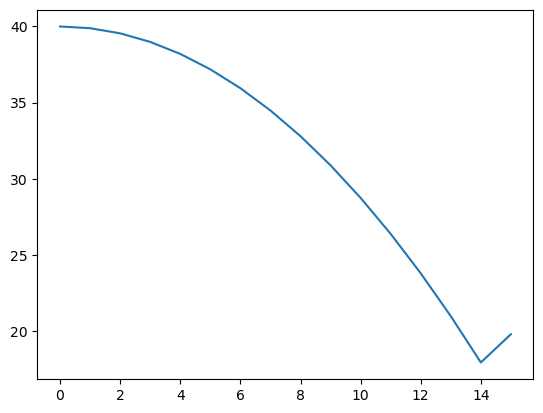

In [27]:
plt.plot(nozzle.history()['H_in'])

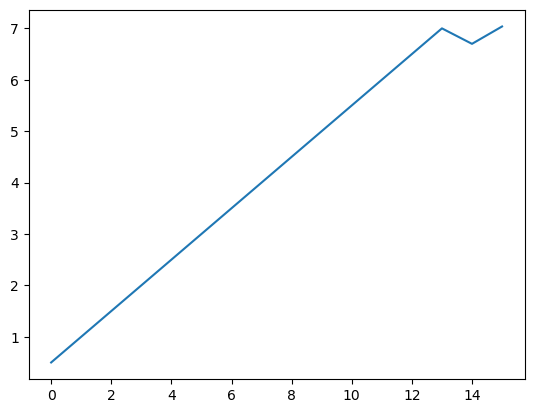

In [28]:
plt.plot(nozzle.history()['q'])

Сходится!!!

In [8]:
10.15 + 0.09 * 5 * 5.03**2

21.535405

# Построим график производительности ствола от напора на насосе

In [33]:
def get_Qnozzle(h_nozzle, p_nozzle):
    return p_nozzle * pow(h_nozzle, 0.5)

def get_Hhose(q_nozzle, s=0.09, n=1):
    return s * n * q_nozzle**2

h_nozzle = 49.55
q_nozzle = get_Qnozzle(h_nozzle, p_10)
h_hose = get_Hhose(q_nozzle, n=5)
h_pump = h_hose + h_nozzle

print('Напор перед стволом    ', h_nozzle, 'м')
print('Расход из ствола       ', q_nozzle, 'л/с')
print('Потеря напора в рукаве ', h_hose, 'м')
print('напор на насосе        ', h_pump, 'м')

Напор перед стволом     49.55 м
Расход из ствола        11.129914644776031 л/с
Потеря напора в рукаве  55.743749999999984 м
напор на насосе         105.29374999999999 м


Text(0.5, 1.0, 'Ствол при расходе 10 л/с')

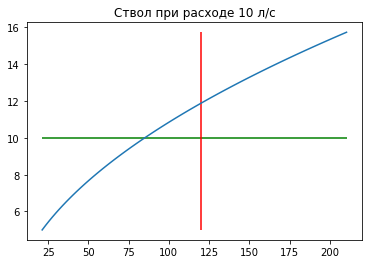

In [ ]:
h_pumps   = []
q_nozzles = []

for h_nozzle in (range(10, 100)):
    q_nozzle = get_Qnozzle(h_nozzle, p_10)
    h_hose = get_Hhose(q_nozzle, n=5)
    h_pump = h_hose + h_nozzle

    q_nozzles.append(
        q_nozzle
        )
    h_pumps.append(
        h_pump
        )

plt.plot(h_pumps, q_nozzles)
plt.hlines([10], h_pumps[0], h_pumps[-1], color='g')
plt.vlines([120], q_nozzles[0], q_nozzles[-1], color='r')
plt.title('При расходе 10 л/с')

Text(0.5, 1.0, 'Ствол при расходе 4 л/с')

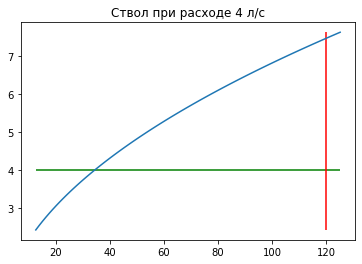

In [ ]:
h_pumps   = []
q_nozzles = []

for h_nozzle in (range(10, 100)):
    q_nozzle = get_Qnozzle(h_nozzle, p_4)
    h_hose = get_Hhose(q_nozzle, n=5)
    h_pump = h_hose + h_nozzle

    q_nozzles.append(
        q_nozzle
        )
    h_pumps.append(
        h_pump
        )

plt.plot(h_pumps, q_nozzles)
plt.hlines([4], h_pumps[0], h_pumps[-1], color='g')
plt.vlines([120], q_nozzles[0], q_nozzles[-1], color='r')
plt.title('При расходе 4 л/с')

Text(0.5, 1.0, 'При расходе 14 л/с')

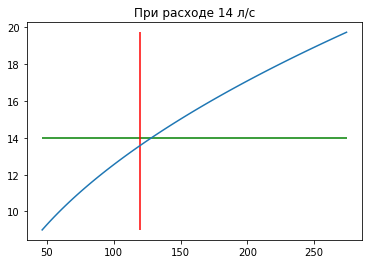

In [48]:
h_pumps   = []
q_nozzles = []

for h_nozzle in (range(10, 100)):
    q_nozzle = get_Qnozzle(h_nozzle, p_10) + 4 #(доп расход от других стволов)
    h_hose = get_Hhose(q_nozzle, n=5)
    h_pump = h_hose + h_nozzle

    q_nozzles.append(
        q_nozzle
        )
    h_pumps.append(
        h_pump
        )

plt.plot(h_pumps, q_nozzles)
plt.hlines([14], h_pumps[0], h_pumps[-1], color='g')
plt.vlines([120], q_nozzles[0], q_nozzles[-1], color='r')
plt.title('При расходе 14 л/с')

Красная линия - максимально возможный напор насоса - 120м.
Зеленая - номинальный расход ствола по ТТХ
Синяя линия - расход ствола при указанном напоре на насосе.

Видно, что если синяя линия пересекает зеленую после красной, значит данная НРС не позволяет обеспечить расход на стволе согласно ТТХ
Если же синяя линия пересекает зеленую до красной, значит НРС работоспособна.